In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/content/drive/MyDrive/student_performance/Titanic-Dataset.csv')

In [19]:
#print no of rows and colunms respectively
df.shape

(891, 12)

In [20]:
# print name of all colunms
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [21]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [23]:
# since cabin is not useful for our analysis and it has null values in huge amount so lets drop colunm cabin
df.drop(columns=['Cabin'],inplace=True)


In [24]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [25]:
# Since Embarked has only 2 null values, so fill it by mode
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

/tmp/ipykernel_14513/3643824464.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [26]:
# Age has few more null values...and we have to perform analysis on age , so using median to fill null values.
df['Age'].fillna(df['Age'].median(),inplace=True)

/tmp/ipykernel_14513/17815158.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [27]:
df.isnull().sum() # no null values

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [28]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


Since, **Age,Cabin and Embarked** were columns having null values.AGE had 177 null value. though this column is required so instead of deleting this column we are going to fill this by median of age.
Cabin has 600+ null values out of 800 + dataset , also it is not iportant feature so delete this colunm using drop() function .
Embarked has only 2 null values and it is categorical value so it is best to fill it using mode.

There are 11 variables present of different datatypes.
PassengerId	 int
Survived	int
Pclass	 int
Name	 object
Sex	 object
Age	  float
SibSp	  int
Parch	   int
Ticket	 object
Embarked	object


In [29]:
# Taking a sample
sample=df.sample(n=100,random_state=42)
sample.shape

(100, 11)

In [33]:
# computing mean of sample(age) and population
print("Mean of population is : ",df['Age'].mean())
print("Mean of sample is : ",sample['Age'].mean())

Mean of population is :  29.36158249158249
Mean of sample is :  29.335


YES, the mean of sample age and population age is approximately equal, which inicates that we can make analysis on sample and then assume that it is also true for whole population which is true in reality.


We use sample rather than population because it is easy to work ,handle and analyse less data when results are same for both.
to collect the entire data is not possible every time and it will be time and sources consuming.
Sample allows us to work efficiently and in better way by using less resources and time.

In [37]:
# creating 500 samples and storing their mean(age)
samples_mean=[]
for i in range(500):
  sample=df.sample(n=30,replace=True) # if we write random state=42 here it will fix the sample and we will have same sample for 500 times
  samples_mean.append(sample['Age'].mean())
print("Mean is \n",samples_mean)

Mean is 
 [np.float64(30.366666666666667), np.float64(28.516666666666666), np.float64(28.566666666666666), np.float64(26.308333333333334), np.float64(30.727666666666668), np.float64(31.3), np.float64(31.35), np.float64(29.283333333333335), np.float64(23.175), np.float64(28.866666666666667), np.float64(26.516666666666666), np.float64(30.033333333333335), np.float64(29.233333333333334), np.float64(26.3), np.float64(29.464), np.float64(28.433333333333334), np.float64(34.28333333333333), np.float64(25.40566666666667), np.float64(27.8), np.float64(28.891666666666666), np.float64(35.9), np.float64(29.066666666666666), np.float64(27.066666666666666), np.float64(28.4), np.float64(27.816666666666666), np.float64(27.266666666666666), np.float64(31.066666666666666), np.float64(27.739), np.float64(26.15), np.float64(31.25), np.float64(30.38066666666667), np.float64(27.716666666666665), np.float64(28.583333333333332), np.float64(29.93066666666667), np.float64(32.8), np.float64(29.533333333333335), 

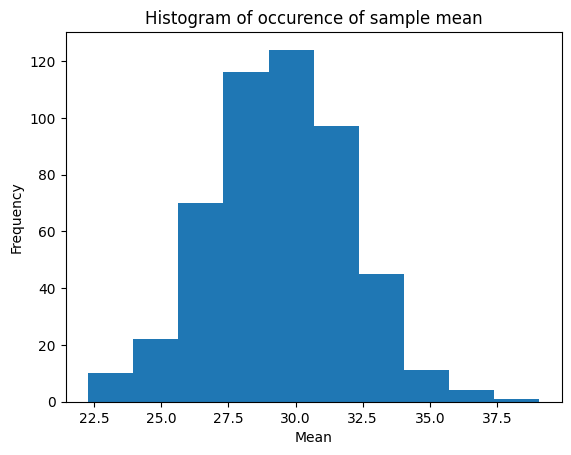

In [38]:
# plot histogram
plt.hist(samples_mean)
plt.title('Histogram of occurence of sample mean')
plt.xlabel('Mean')
plt.ylabel('Frequency')
plt.show()

The shape of histogram is bell-curve which is normal distribution as the center of histoogram is around 29 . it is symmetrically spread on both sides.

Ths happens due to **central limit theory**. which says that even if original data or entire population is not normally distributed but when wwe take multiple samples  and compute their mean ,they show normal behaviour and their distriution become normal( bell-curve).
so our case also supprt central liit theory and distribution of sample means tend to norml distribution regardless of population distribution.

In [42]:
# compute sample mean and standard deviation

print("Mean of sample is: ",sample['Age'].mean())
print("Standard Deviation of sample is: ",sample['Age'].std())


Mean of sample is:  25.08066666666667
Standard Deviation of sample is:  10.374007948692746


In [45]:
# computing confidence interval using{mean +- [Z.(s/n)]}
x=sample['Age'].mean()
s=sample['Age'].std()
n=len(sample)
z=1.96 # for 95% confidence interval
lower=x-z*(s/np.sqrt(n))
upper=x+z*(s/np.sqrt(n))
print("Confidence Interval:", (int(lower), int(upper)))


Confidence Interval: (21, 28)


This interval represents that we are 95% confident that the population age mean lies within this interval.It tells the uncertainty in estimating the population parameter using sample data.

As sample size increases, this interval will become more narrow as range is inversly proportional to square root of sample size. which represents less confidence in estimating mean of population.

In [2]:
# Define hypothesis.

# H0(Null Hypothesis)=No difference in survival.
# H1(lternative hypothesis)=There is difference in survival rate
from scipy import stats


In [8]:
male=df[df['Sex']=='male']['Survived']
female=df[df['Sex']=='female']['Survived']

t_stat, p_value = stats.ttest_ind(male, female)
print("t-stat:", t_stat)
print("p-value:", p_value)
# here we are choosing significance level =0.05 (most common one)
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

t-stat: -19.297816550123354
p-value: 1.4060661308802594e-69
Reject Null Hypothesis


**p-value measures how strong the evidence is against the null hypothesis.** In our case, p value is 1.4060661308802594e-69 which is less than 0.05 which shows that we have to reject null hypothesis. It means that our assumption that** gender has no difference in survival is false**.So,we can conclude that gender has significance role in survival .

In [10]:
print("Male survival rate:", male.mean())
print("Female survival rate:", female.mean())

Male survival rate: 0.18890814558058924
Female survival rate: 0.7420382165605095


Yes Gender affects survival . Female survival rate is significantly higher than male.

Yes, this conclusion can be trusted because statistical hypothesis testing was used, and the p-value was less than the significance level (0.05), indicating that the result is statistically significant.

This analysis assume that

*   Sample is randomly selected.
*   The data is sufficient to represent whole population
*   Observations are independent.
  





The findings suggest that gender played a significant role in survival, possibly due to social norms and rescue priorities at the time. Such analysis helps in identifying important factors affecting outcomes and supports data-driven decision-making.

In [12]:
df['Pclass'].unique()    #shows unique value present in pclass column

array([3, 1, 2])

In [15]:
# For passenger class
# defining hypothesis
# H0= no ffect of passanger class on survival
#H1=Significant effect of passenger class on survival


Pclass_1=df[df['Pclass']==1]['Survived']
Pclass_2=df[df['Pclass']==2]['Survived']
Pclass_3=df[df['Pclass']==3]['Survived']


f_statistics, p_value = stats.f_oneway(Pclass_1, Pclass_2, Pclass_3)
print("f_statistic:",f_statistics)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")




f_statistic: 57.96481759091002
p-value: 2.183247415118226e-24
Reject Null Hypothesis


In [16]:
print("Survival Rate of passanger class 1 :",Pclass_1.mean())
print("Survival Rate of passanger class 2 :",Pclass_2.mean())
print("Survival Rate of passanger class 3 :",Pclass_3.mean())


Survival Rate of passanger class 1 : 0.6296296296296297
Survival Rate of passanger class 2 : 0.47282608695652173
Survival Rate of passanger class 3 : 0.24236252545824846


From the above Hypothesis test, we can conclude that passanger class significantly affect the survival. It shows that passanger class 1 people are survived in high number maybe because they are important person of society so the rescue team saved them firstly. and than passenger class 2 is saved and lest likely passanger class 3 has survival.